In [149]:
import numpy as np
import matplotlib.pyplot as plt

import pyaccel
from pymodels import si


In [150]:
m = si.create_accelerator()
famdata = si.get_family_data(m)
print(m)

energy         : 3000000000.0 eV
harmonic_number: 864
cavity_on      : False
radiation_on   : 0
vchamber_on    : False
lattice version: SI_V25_04_1.21.3
lattice size   : 6752
lattice length : 518.3898999999917 m


In [151]:
# famdata.keys()

In [152]:
spos = pyaccel.lattice.find_spos(m, indices='open')
bpm_indices = pyaccel.lattice.find_indices(m, 'fam_name', 'BPM')
print(len(bpm_indices))
ivu_indices = pyaccel.lattice.find_indices(m, 'fam_name', 'IVU18')
print(ivu_indices)
ivu1_indices = ivu_indices[:2]
ivu2_indices = ivu_indices[2:]

160
[2356, 2358, 4376, 4378]


In [153]:
def set_ivu_kick(m, ivu_indices, vkick):
    
    for idx in ivu_indices:
        m[idx].pass_method = 'str_mpole_symplectic4_pass'
        m[idx].vkick_polynom = vkick


In [154]:
# set_ivu_kick(m, ivu1_indices, +1*5e-6/2)
# print(m[ivu1_indices[0]])

In [155]:
cod_before = pyaccel.tracking.find_orbit4(m, indices='open')  # cod before kick

In [156]:
cod_before.shape

(4, 6752)

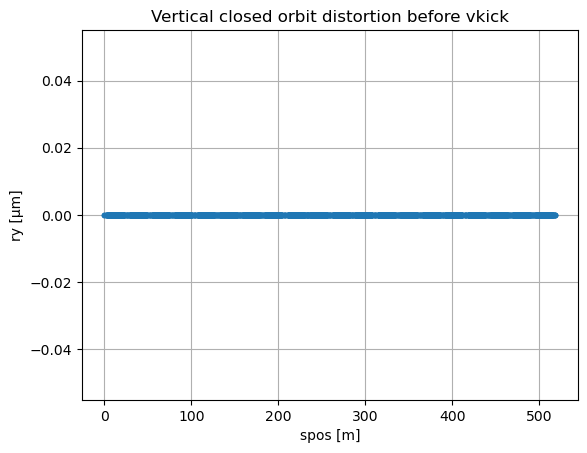

In [157]:
plt.plot(spos, 1e6*cod_before[2,:], '.-')
plt.title('Vertical closed orbit distortion before vkick')
plt.xlabel('spos [m]')
plt.ylabel('ry [µm]')
plt.grid()
plt.show()

In [158]:
delta_vkick = 5e-6  # [rad]

set_ivu_kick(m, ivu1_indices, +1*delta_vkick/2)
cod_after = pyaccel.tracking.find_orbit4(m, indices='open')

set_ivu_kick(m, ivu1_indices, 0)

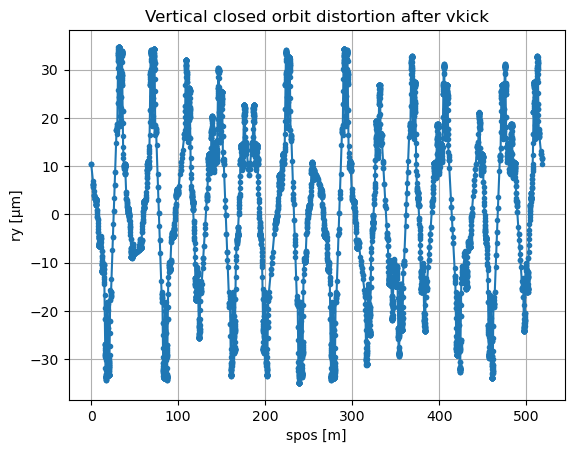

In [159]:
plt.plot(spos, 1e6*cod_after[2,:], '.-')
plt.title('Vertical closed orbit distortion after vkick')
plt.xlabel('spos [m]')
plt.ylabel('ry [µm]')
plt.grid()
plt.show()

Calculate ORM:

In [160]:
delta_vkick = 5e-6  # [rad]

set_ivu_kick(m, ivu1_indices, +1*delta_vkick/2)
cod_pos = pyaccel.tracking.find_orbit4(m, indices='open')

set_ivu_kick(m, ivu1_indices, -1*delta_vkick/2)
cod_neg = pyaccel.tracking.find_orbit4(m, indices='open')

set_ivu_kick(m, ivu1_indices, 0)

In [161]:
n_bpms = len(bpm_indices)

orm = np.zeros((2*n_bpms, 1))

orm.shape

(320, 1)

In [162]:
orm[:n_bpms, 0] = (cod_pos[0, bpm_indices] - cod_neg[0, bpm_indices])/delta_vkick
orm[n_bpms:, 0] = (cod_pos[2, bpm_indices] - cod_neg[2, bpm_indices])/delta_vkick
print(max(orm))

[11.03284679]


In [163]:
orm[:n_bpms, 0] = (cod_pos[0, bpm_indices] - cod_neg[0, bpm_indices])/delta_vkick
orm[n_bpms:, 0] = (cod_pos[2, bpm_indices] - cod_neg[2, bpm_indices])/delta_vkick
print(max(orm))

[11.03284679]


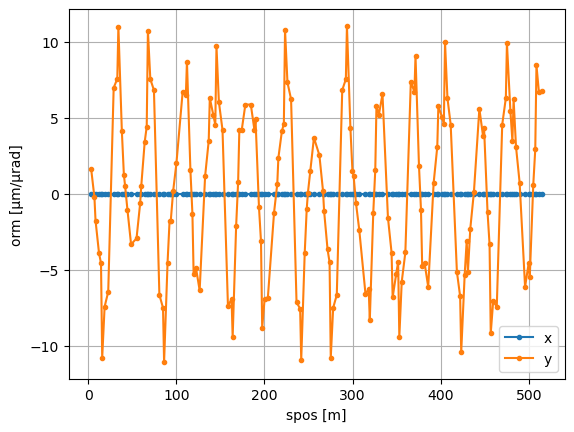

In [164]:
spos_bpms = spos[bpm_indices]
plt.plot(spos_bpms, orm[:n_bpms, 0], '.-', label='x')
plt.plot(spos_bpms, orm[n_bpms:, 0], '.-', label='y')
plt.xlabel('spos [m]')
plt.ylabel('orm [µm/µrad]')
plt.legend()
plt.grid()
plt.show()